In [134]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [216]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [12, 7.42]
color_m1, color_m2 = "#1565C0", "#2E7D32"
h = 0.001
t20, t30, t50 = np.arange(0, 20, h), np.arange(0, 30, h), np.arange(0, 50, h)

Un sistema fisico che esprime sensibilità alla variazione delle condizioni iniziali, anche minime, è chiamato **caotico**: cioè, pur rimanendo deterministico, ha un'evoluzione nel tempo difficilmente prevedibile e calcolabile.

Un classico esempio di sistema caotico è rappresentato dal doppio pendolo: alla massa di un pendolo semplice viene collegata, mediante un'asta rigida, una seconda massa. L'oscillazione di questo sistema è fortemente sensibile alle condizioni iniziali, al punto che anche variazioni dell'ordine del milionesimo di grado portano ad evoluzioni completamente diverse.

In questa simulazione utilizzeremo il metodo di Runge-Kutta 4 al posto di Velocity-Verlet. Quest'ultimo può essere applicato a problemi in cui le hamiltoniane sono separabili, ma nel doppio pendolo l'energia cinetica dipende anche dagli angoli che le due aste rigide formano con la verticale. La sua implementazione rimane possibile ma diverrebbe molto complicata.

In [230]:
def acc(x1: float, v1: float, x2: float, v2: float, L1: float = 1.0, L2: float = 1.0, m1: float = 1.0, m2: float = 1.0) -> tuple[float, float, float, float]:
    """
    Funzione che accetta 4 parametri, i primi due legati alla posizione e gli ultimi due legati alla velocità, 
    e restituisce un vettore di lunghezza 4 che contiene le derivate prime dei parametri in entrata:
    detti x1, v1, x2, v2 i parametri in entrata restituisce v1, a1, v2, a2.
    """
    g = 9.81
    dx = x1 - x2
    
    num1 = -g * (2*m1 + m2) * np.sin(x1) - m2 * g * np.sin(x1 - 2*x2) - 2 * np.sin(dx) * m2 * (v2**2 * L2 + v1**2 * L1 * np.cos(dx))
    den1 = L1 * (2*m1 + m2 - m2 * np.cos(2*dx))
    a1 = num1/den1
    
    num2 = 2 * np.sin(dx) * (v1**2 * L1 * (m1 + m2) + g * (m1 + m2) * np.cos(x1) + v2**2 * L2 * m2 * np.cos(dx))
    den2 = L2 * (2*m1 + m2 - m2 * np.cos(2*(dx)))
    a2 = num2/den2
    
    return v1, a1, v2, a2

In [178]:
def rk4(theta1: float, theta2: float, omega1: float, omega2: float, h: float, times: list[float], f: callable) -> tuple[list[float], list[float], list[float], list[float]]:
    h_mezzi, h_sesti = h/2, h/6
    p1, v1 = np.zeros(len(times)), np.zeros(len(times))
    p2, v2 = np.zeros(len(times)), np.zeros(len(times))

    p1[0], v1[0], p2[0], v2[0] = theta1, omega1, theta2, omega2

    for i in range(1, len(times)):
        k1x1, k1v1, k1x2, k1v2 = f(p1[i-1], v1[i-1], p2[i-1], v2[i-1])
        k2x1, k2v1, k2x2, k2v2 = f(p1[i-1] + h_mezzi * k1x1, v1[i-1] + h_mezzi * k1v1, p2[i-1] + h_mezzi * k1x2, v2[i-1] + h_mezzi * k1v2)
        k3x1, k3v1, k3x2, k3v2 = f(p1[i-1] + h_mezzi * k2x1, v1[i-1] + h_mezzi * k2v1, p2[i-1] + h_mezzi * k2x2, v2[i-1] + h_mezzi * k2v2)
        k4x1, k4v1, k4x2, k4v2 = f(p1[i-1] + h * k3x1, v1[i-1] + h * k3v1, p2[i-1] + h * k3x2, v2[i-1] + h * k3v2)

        p1[i] = p1[i-1] + h_sesti * (k1x1 + 2*k2x1 + 2*k3x1 + k4x1)
        v1[i] = v1[i-1] + h_sesti * (k1v1 + 2*k2v1 + 2*k3v1 + k4v1)
        p2[i] = p2[i-1] + h_sesti * (k1x2 + 2*k2x2 + 2*k3x2 + k4x2)
        v2[i] = v2[i-1] + h_sesti * (k1v2 + 2*k2v2 + 2*k3v2 + k4v2)
    return p1, v1, p2, v2

h = 0.001
times = np.arange(0, 20, h)

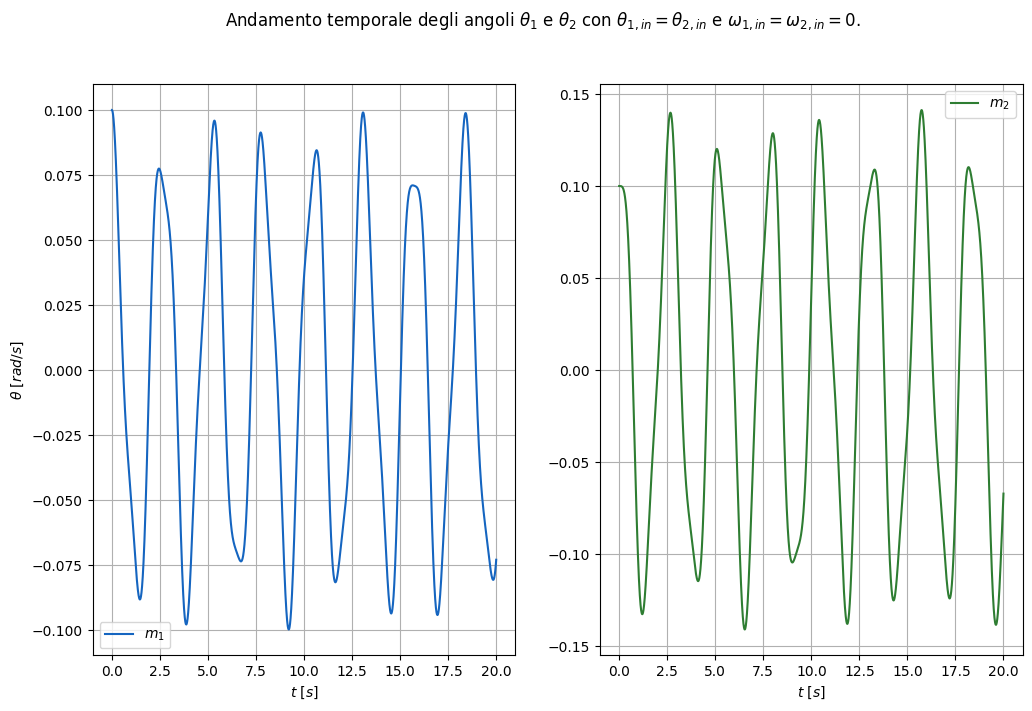

In [217]:
p1, v1, p2, v2 = rk4(theta1=0.1, theta2=0.1, omega1=0.0, omega2= 0.0, h=h, times=t20, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(times, p1, color=color_m1, label=r"$m_1$")
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\theta\ [rad/s]$")
ax1.grid(True)
ax1.legend()

ax2.plot(times, p2, color=color_m2, label=r"$m_2$")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)
ax2.legend()

plt.suptitle(r"Andamento temporale degli angoli $\theta_1$ e $\theta_2$ con $\theta_{1,in}=\theta_{2,in}$ e $\omega_{1,in}=\omega_{2,in}=0$.")
plt.show()

Nell'andamento angolare dei due corpi con condizioni iniziali di piccoli angoli, notiamo che il moto rimane quasi periodico, ma le ampiezze non rimangono costanti. Anche se RK4 non è un metodo simplettico, per tempi di simulazione brevi l'energia totale del sistema si conserva (non ci sono attriti dissipativi), ma c'è uno scambio di energia tra le due masse: quando la prima raggiunge dei massimi d'ampiezza, la seconda raggiunge dei minimi e viceversa (fenomeno dei **battimenti**).

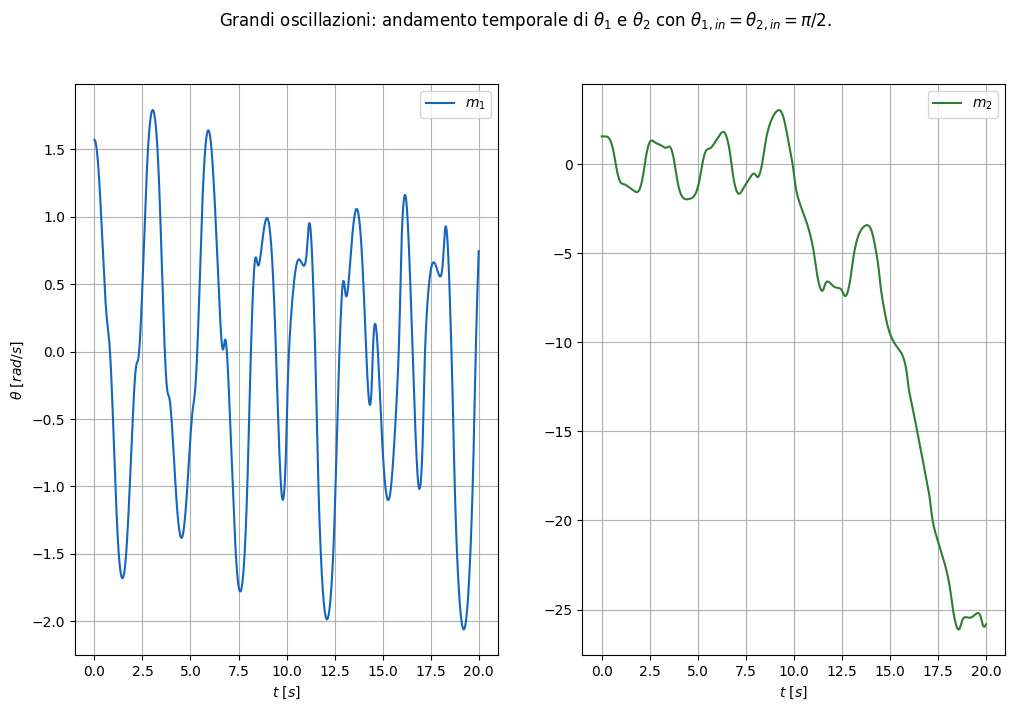

In [218]:
p1, v1, p2, v2 = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2= 0.0, h=h, times=t20, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(times, p1, color=color_m1, label=r"$m_1$")
ax1.set_xlabel(r"$t\ [s]$")
ax1.set_ylabel(r"$\theta\ [rad/s]$")
ax1.grid(True)
ax1.legend()

ax2.plot(times, p2, color=color_m2, label=r"$m_2$")
ax2.set_xlabel(r"$t\ [s]$")
ax2.grid(True)
ax2.legend()

plt.suptitle(r"Grandi oscillazioni: andamento temporale di $\theta_1$ e $\theta_2$ con $\theta_{1,in}=\theta_{2,in}=\pi/2$.")
plt.show()

Quando entriamo nel regime di grandi oscillazioni ($\theta_{1,in}=\theta_{2,in}=\pi/2$), notiamo che la prima massa compie un moto che ricorda vagamente quello periodico di un pendolo semplice, mentre la seconda perde qualsivoglia caratteristica dell'oscillatore armonico. Questo accade perché la prima massa è collegata, mediante la propria asta, ad un perno fisso, mentre la seconda, essendo collegata alla prima massa, è come se avesse un perno mobile.

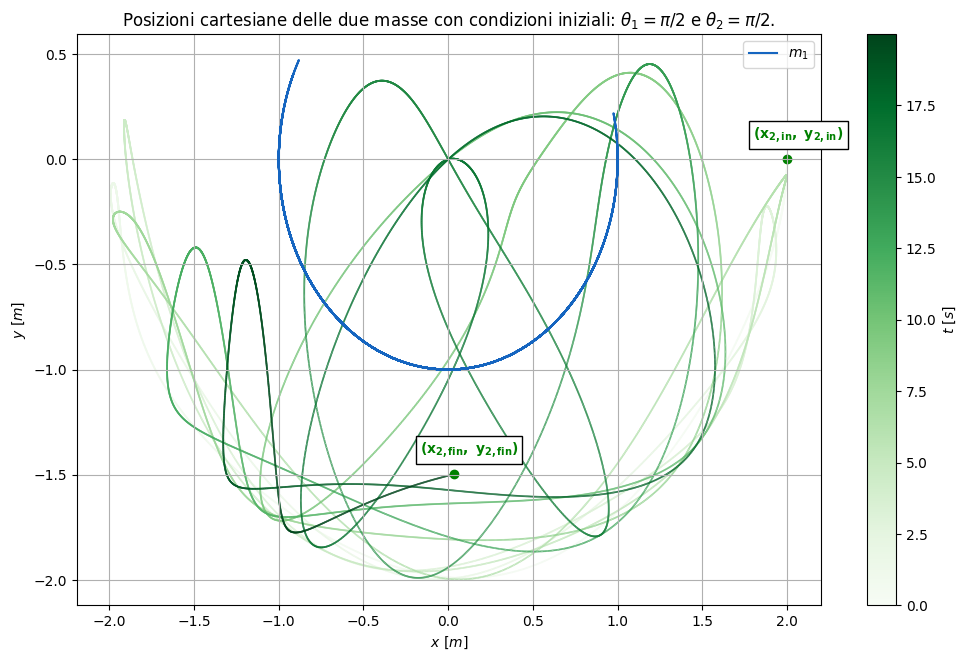

In [220]:
x1, y1 = np.sin(p1), -np.cos(p1)
x2, y2 = x1 + np.sin(p2), y1 - np.cos(p2)

plt.plot(x1, y1, color=color_m1, label=r"$m_1$")
plt.scatter(x2, y2, c=times, cmap="Greens", s=0.1)
plt.colorbar(label=r"$t\ [s]$")
plt.grid()
plt.xlabel(r"$x\ [m]$")
plt.ylabel(r"$y\ [m]$")
plt.title(r"Posizioni cartesiane delle due masse con condizioni iniziali: $\theta_1=\pi/2$ e $\theta_2=\pi/2$.")
plt.scatter(x2[0], y2[0], color="green")
plt.text(x2[0]-0.2, y2[0]+0.1, s=r"$\mathbf{(x_{2,in},\ y_{2,in})}$", fontweight="bold", color="green", fontsize=10, bbox=dict(facecolor="white", edgecolor="black", alpha=1, boxstyle="square", pad=0.3))
plt.scatter(x2[-1], y2[-1], color="green")
plt.text(x2[-1]-0.2, y2[-1]+0.1, s=r"$\mathbf{(x_{2,fin},\ y_{2,fin})}$", fontweight="bold", color="green", fontsize=10, bbox=dict(facecolor="white", edgecolor="black", alpha=1, boxstyle="square", pad=0.3))
plt.legend()
plt.show()

Questa differenza nei moti delle due masse è ancora più evidente nel grafico che riporta le posizioni cartesiane dei due corpi: notiamo nuovamente che il primo corpo compie un moto vagamente periodico, anche se nella sua evoluzione compie cambi di verso poco prevedibili e non distinguibili dal grafico statico, mentre il secondo corpo ha un andamento completamente caotico.

Nel grafico sono stati evidenziati i punti iniziale e finale del moto della seconda massa.

In [141]:
def energy(x1: float, v1: float, x2: float, v2: float, m1: float = 1, m2: float = 1, L1: float = 1, L2: float = 1) -> float:
    g = 9.81
    kin = 0.5 * m1 * L1**2 * v1**2 + 0.5 * m2 * (L1**2 * v1**2 + L2**2 * v2**2 + 2 * L1 * L2 * v1 * v2 * np.cos(x1-x2))
    pot = -(m1 + m2) * g * L1 * np.cos(x1) - m2 * g * L2 * np.cos(x2)

    return kin + pot

1.3685733936989899e-12


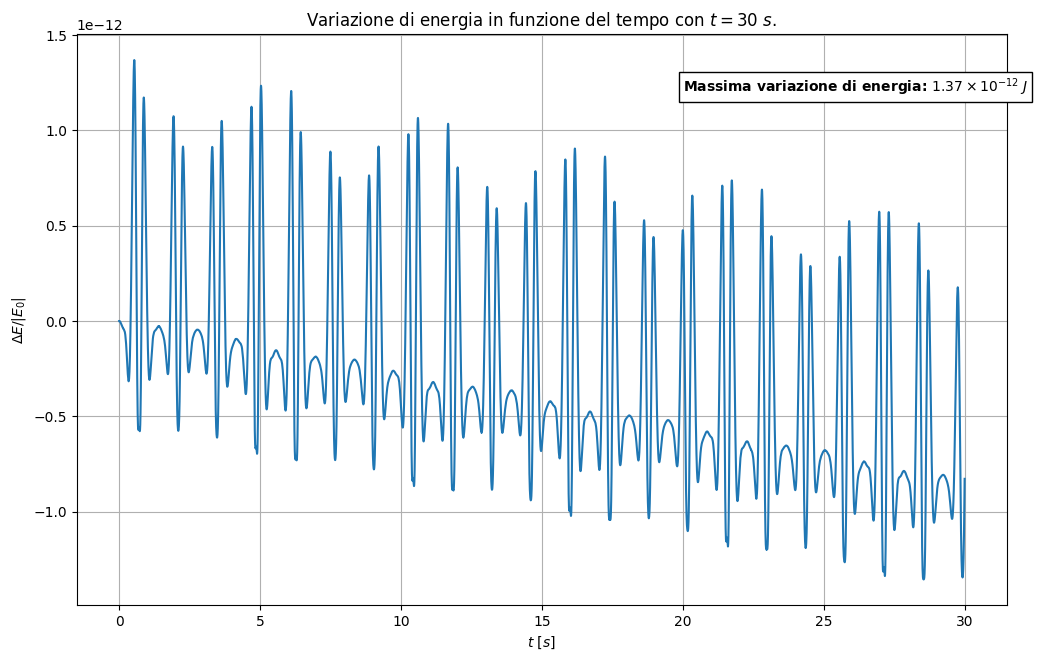

In [254]:
p1, v1, p2, v2 = rk4(theta1=np.pi/3, theta2=np.pi/3, omega1=0.0, omega2= 0.0, h=h, times=t30, f=acc)
en = energy(x1=p1, v1=v1, x2=p2, v2=v2)
en0 = energy(x1=np.pi/3, v1=0.0, x2=np.pi/3, v2=0.0)
max_var_en = np.max((en-en0)/abs(en0))
print(max_var_en)
plt.plot(t30, (en-en0)/abs(en0))
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\Delta E/|E_0|$")
plt.text(20, 1.2e-12, s=rf"Massima variazione di energia: $1.37\times10^{{-12}}\ J$", fontweight="bold", fontsize=10, bbox=dict(facecolor="white", edgecolor="black", alpha=1, boxstyle="square", pad=0.3))
plt.title(rf"Variazione di energia in funzione del tempo con $t=30\ s$.")
plt.grid()
plt.show()

Aumentando il tempo di simulazione da $t=20\ s$ a $t=30\ s$ notiamo che il metodo RK4 è un metodo non simplettico, infatti c'è una variazione di energia pari a $1.37\times10^{-12}\ J$. Questa variazione conferma però che questo metodo è comunque molto stabile ed affidabile anche per tempi di simulazione lunghi.

In [244]:
p1a, v1a, p2a, v2a = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2=0.0, h=h, times=t30, f=acc)
p1b, v1b, p2b, v2b = rk4(theta1=np.pi/2+10e-6, theta2=np.pi/2+10e-6, omega1=0.0, omega2=0.0, h=h, times=t30, f=acc)

t0 = np.argmax(np.abs(p1a-p1b)>10e-2)
print(t30[t0])

16.934


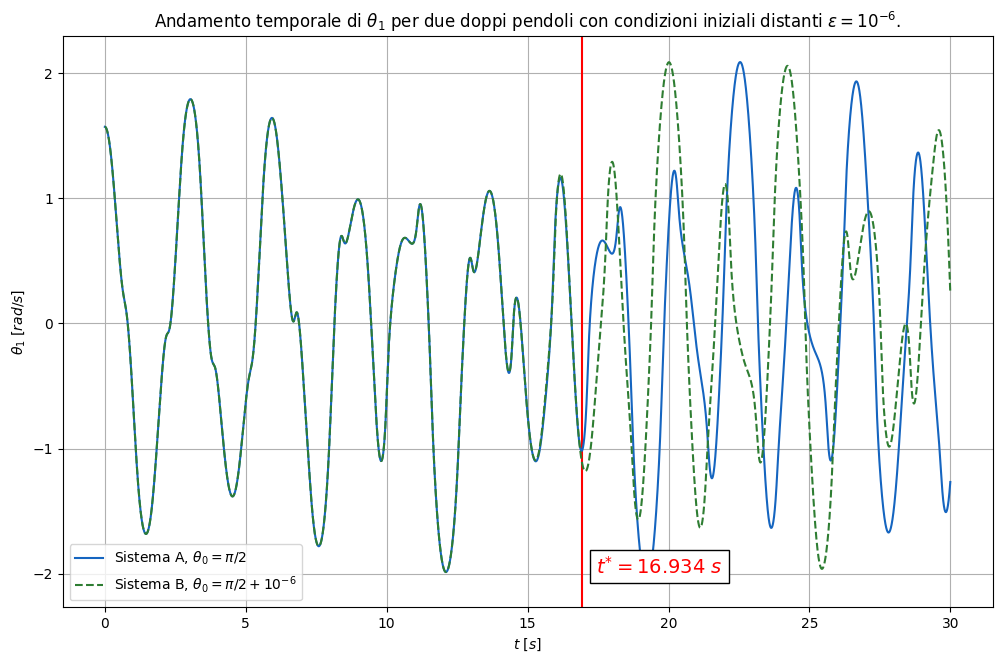

In [249]:
plt.axvline(t30[t0], color="red")
plt.text(t30[t0]+0.5, -2, bbox=dict(facecolor="white", edgecolor="black", alpha=1, boxstyle="square", pad=0.3), s=rf"$t^{{*}}={t30[t0]}\ s$", color="red", fontsize=14)
plt.plot(t30, p1a, label=r"Sistema A, $\theta_0=\pi/2$", color=color_m1)
plt.plot(t30, p1b, "--", label=r"Sistema B, $\theta_0=\pi/2 + 10^{-6}$", color=color_m2)
plt.xlabel(r"$t\ [s]$")
plt.ylabel(r"$\theta_1\ [rad/s]$")
plt.title(r"Andamento temporale di $\theta_1$ per due doppi pendoli con condizioni iniziali distanti $\varepsilon=10^{-6}$.")
plt.grid()
plt.legend()
plt.show()

Simulando due pendoli con condizioni iniziali che distano fra loro $10^{-6}\ rad$, notiamo che dopo soli $t^{*}=16.93\ s$ le traiettorie iniziano a divergere.

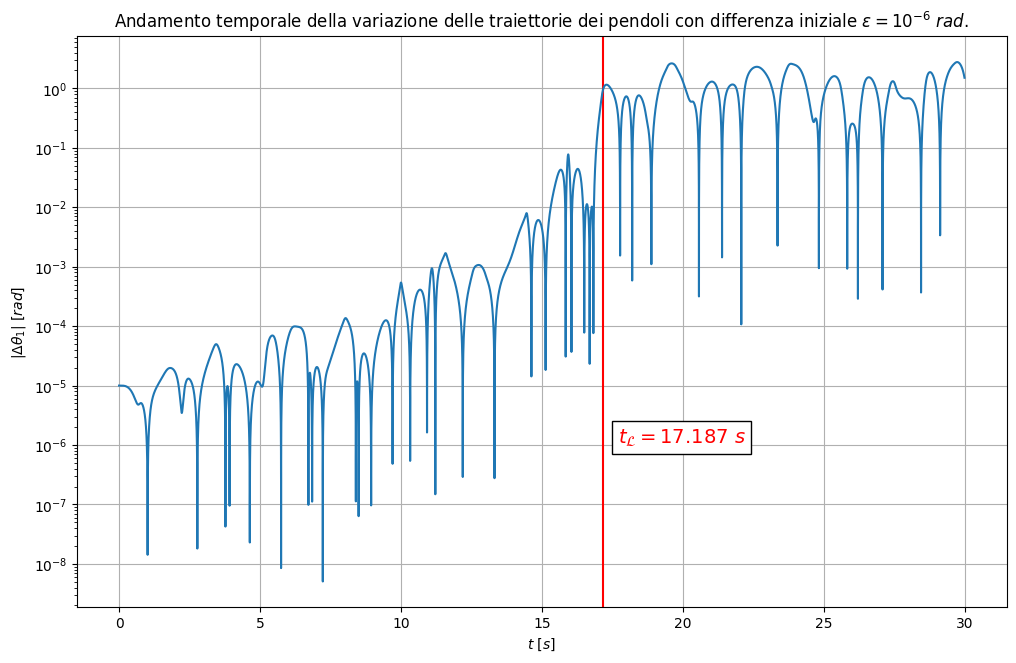

In [252]:
dtheta = np.abs(p1a-p1b)
t_ljapunov = np.argmax(dtheta>1)
plt.axvline(t30[t_ljapunov], color="red")
plt.text(t30[t_ljapunov]+0.5, 10e-8+10e-7, bbox=dict(facecolor="white", edgecolor="black", alpha=1, boxstyle="square", pad=0.3), s=rf"$t_{{\mathcal{{L}}}}={t30[t_ljapunov]}\ s$", color="red", fontsize=14)
plt.plot(t30, dtheta)
plt.xlabel(r"$t\ [s]$")
plt.yscale("log")
plt.ylabel(r"$|\Delta\theta_1|\ [rad]$")
plt.title(r"Andamento temporale della variazione delle traiettorie dei pendoli con differenza iniziale $\varepsilon=10^{-6}\ rad$.")
plt.grid()
plt.show()

In questo grafico si può notare come inizialmente le traiettorie si allontanino esponenzialmente: questa è l'indicazione di un andamento caotico e $t_{\mathcal{L}}$ è chiamato **tempo di Ljapunov**, e indica l'orizzonte temporale entro il quale è possibile fare una previsione affidabile. All'aumentare del tempo di Ljapunov, le previsioni sull'evoluzione dei sistemi diventano più accurate, mentre sistemi con tempi di Ljapunov piccoli sono molto imprevedibili.

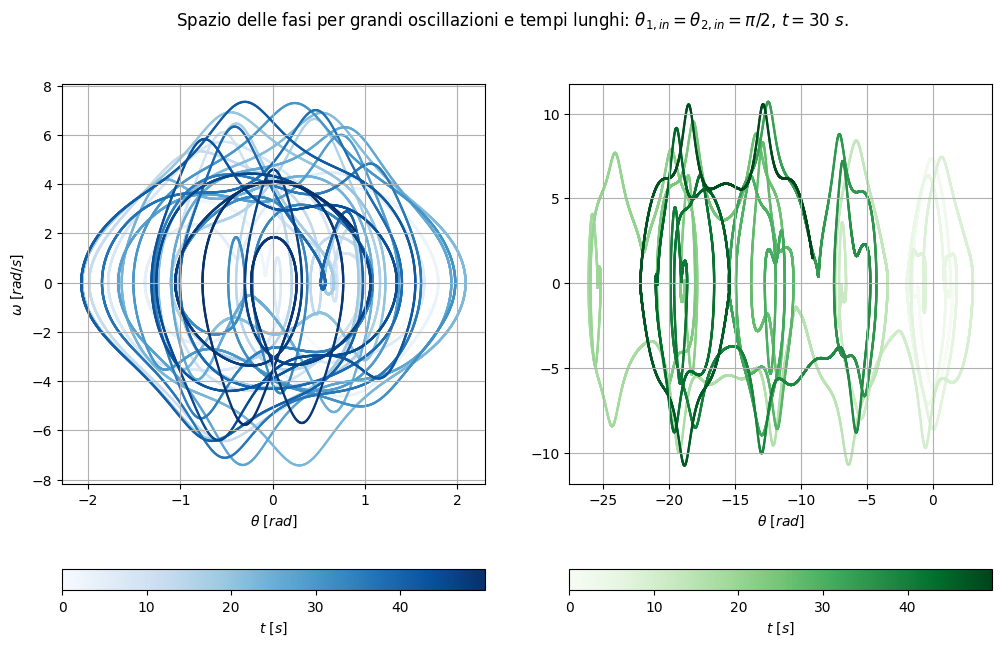

In [253]:
p1, v1, p2, v2 = rk4(theta1=np.pi/2, theta2=np.pi/2, omega1=0.0, omega2= 0.0, h=h, times=t50, f=acc)
fig, (ax1, ax2) = plt.subplots(1, 2)
sc1 = ax1.scatter(p1, v1, c=t50, cmap="Blues", s=0.5)
ax1.set_xlabel(r"$\theta\ [rad]$")
ax1.set_ylabel(r"$\omega\ [rad/s]$")
ax1.grid(True)

sc2 = ax2.scatter(p2, v2, c=t50, cmap="Greens", s=0.5)
ax2.set_xlabel(r"$\theta\ [rad]$")
ax2.grid(True)

fig.colorbar(sc1, ax=ax1, label=r"$t\ [s]$", orientation="horizontal")
fig.colorbar(sc2, ax=ax2, label=r"$t\ [s]$", orientation="horizontal")
plt.suptitle(r"Spazio delle fasi per grandi oscillazioni e tempi lunghi: $\theta_{1,in}=\theta_{2,in}=\pi/2$, $t=30\ s$.")
plt.show()

A differenza del classico ritratto di fase del pendolo semplice, in cui abbiamo traiettorie chiuse, nel caso del doppio pendolo le traiettorie nello spazio delle fasi delle due masse non sono chiuse, ma occupano una vasta regione: la loro evoluzione non è prevedibile e la loro forma non ricorda più quella di un'ellisse.